In [1]:
%load_ext autoreload
%autoreload 2
    
%matplotlib widget

import numpy as np
from pySEA.sea_eco.models.components.gaussians import Gaussian1D, Gaussian2D, GaussianND
import matplotlib.pyplot as plt

In [2]:
x = np.linspace(-100,100,201)
xy = np.stack(np.meshgrid(x, x, indexing='ij'), axis=-1)
xyz = np.stack(np.meshgrid(x,x,x, indexing='ij'), axis=-1)

In [3]:
mu=[20,10]
sigma = [10, 30]
theta = np.deg2rad(45)

R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

check = np.dot(R[0], R[1])
check, check != 0, not np.isclose(check, 0)

(np.float64(4.266421588589642e-17), np.True_, False)

In [4]:
np.isclose(1E-17, 0)

np.True_

Text(0.0, 1.0, 'Set covariance')

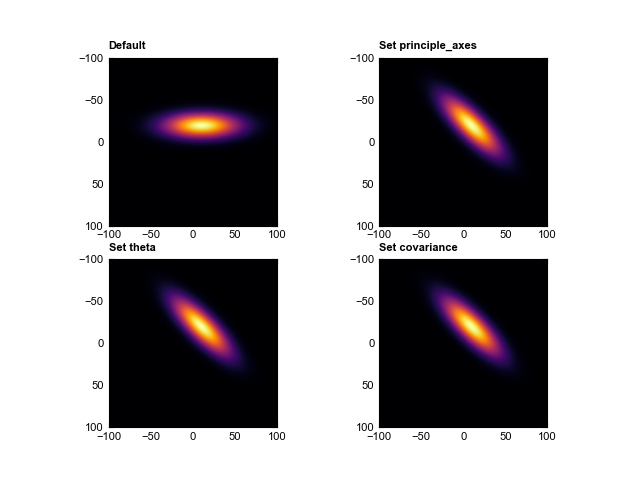

In [5]:
mu=[20,10]
sigma = [10, 30]
theta = np.deg2rad(45)

R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
D = np.diag(sigma)**2
S = R @ D @ R.T

# Initialize figure
fig, axs = plt.subplots(ncols=2, nrows=2)

# Generate non-rotated 2D-Gaussian via theta
G2 = Gaussian2D(A=100, mu=mu , sigma=sigma)
axs[0,0].imshow(G2.evaluate(xy),
           extent=(-100, 100, 100, -100), origin='lower')
axs[0,0].set_title('Default')

#G2.theta = theta #TODO: allow update of covariance when theta or principle_axes change
G2 = Gaussian2D(A=100, mu=mu , sigma=sigma, theta=theta)
axs[1,0].imshow(G2.evaluate(xy),
           extent=(-100, 100, 100, -100), origin='lower')
axs[1,0].set_title('Set theta')

G2 = Gaussian2D(A=100, mu=mu , sigma=sigma, principle_axes=R)
axs[0,1].imshow(G2.evaluate(xy),
           extent=(-100, 100, 100, -100), origin='lower')
axs[0,1].set_title('Set principle_axes')

G2 = Gaussian2D(A=100, mu=mu , sigma=sigma)
G2.covariance = S
axs[1,1].imshow(G2.evaluate(xy),
           extent=(-100, 100, 100, -100), origin='lower')
axs[1,1].set_title('Set covariance')

The gaussians can be paramaterized with either `sigma` or `fwhm` and either `A` or `height`

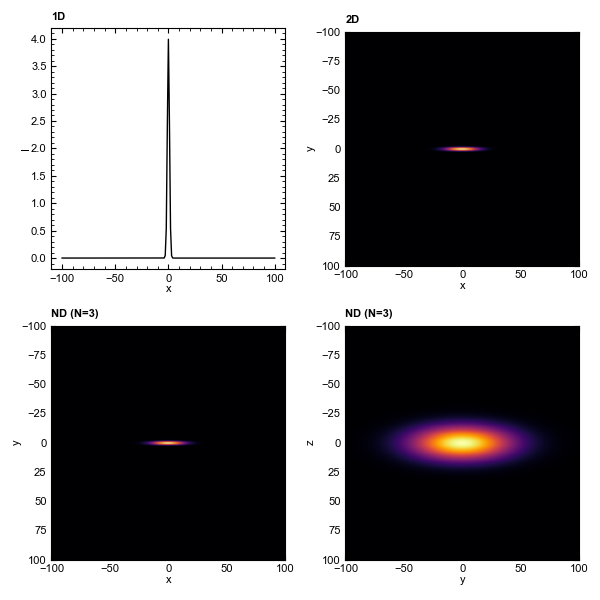

In [6]:
G1 = Gaussian1D(A=10, mu=0 , sigma=1)
G2 = Gaussian2D(A=100, mu=(0,)*2 , sigma=[1,10])
GN = GaussianND(A=100, mu=(0,)*3 , sigma=[1,10,30])

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(6,6))
axs[0,0].plot(x, G1.evaluate(x))
axs[0,0].set_xlabel('x')
axs[0,0].set_ylabel('I')
axs[0,0].set_title('1D')

axs[0,1].imshow(G2.evaluate(xy),
              extent=(-100, 100, 100, -100),
              origin='lower')
axs[0,1].set_xlabel('x')
axs[0,1].set_ylabel('y')
axs[0,1].set_title('2D')

axs[1,0].imshow(GN.evaluate(xyz)[...,x.size//2],
              extent=(-100, 100, 100, -100),
              origin='lower')
axs[1,0].set_xlabel('x')
axs[1,0].set_ylabel('y')
axs[1,0].set_title('ND (N=3)')

axs[1,1].imshow(GN.evaluate(xyz)[x.size//2],
              extent=(-100, 100, 100, -100),
              origin='lower')
axs[1,1].set_xlabel('y')
axs[1,1].set_ylabel('z')
axs[1,1].set_title('ND (N=3)')

fig.tight_layout()

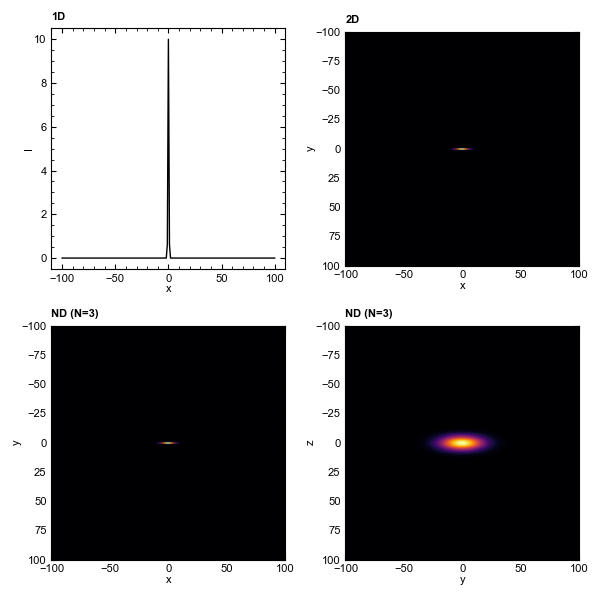

In [7]:
G1 = Gaussian1D(height=10,  mu=0,      fwhm=1)
G2 = Gaussian2D(height=100, mu=(0,)*2, fwhm=[1,10])
GN = GaussianND(height=100, mu=(0,)*3, fwhm=[1,10,30])

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(6,6))
axs[0,0].plot(x, G1.evaluate(x))
axs[0,0].set_xlabel('x')
axs[0,0].set_ylabel('I')
axs[0,0].set_title('1D')

axs[0,1].imshow(G2.evaluate(xy),
              extent=(-100, 100, 100, -100),
              origin='lower')
axs[0,1].set_xlabel('x')
axs[0,1].set_ylabel('y')
axs[0,1].set_title('2D')

axs[1,0].imshow(GN.evaluate(xyz)[...,x.size//2],
              extent=(-100, 100, 100, -100),
              origin='lower')
axs[1,0].set_xlabel('x')
axs[1,0].set_ylabel('y')
axs[1,0].set_title('ND (N=3)')

axs[1,1].imshow(GN.evaluate(xyz)[x.size//2],
              extent=(-100, 100, 100, -100),
              origin='lower')
axs[1,1].set_xlabel('y')
axs[1,1].set_ylabel('z')
axs[1,1].set_title('ND (N=3)')

fig.tight_layout()